In [2]:
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define the network
class MultilayerNet(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes):
        super(MultilayerNet, self).__init__()
        self.layers = nn.ModuleList()
        
        # Input layer
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        
        # Hidden layers
        for i in range(len(hidden_sizes) - 1):
            self.layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
        
        # Output layer
        self.layers.append(nn.Linear(hidden_sizes[-1], num_classes))

    def forward(self, x):
        for layer in self.layers:
            x = torch.relu(layer(x))
        return x

# Function to normalize input data
def normalize_data(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    X_normalized = (X - mean) / (std + 1e-8)  # Avoid division by zero
    return X_normalized

# Whiten the data using the function you provided
# def whiten_data(data):
#     # Compute covariance matrix
#     cov_matrix = np.cov(data.T)
#     # Perform eigendecomposition
#     eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
#     # Form whitening transformation matrix
#     whitening_matrix = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues + 1e-5)) @ eigenvectors.T
#     # Apply whitening transformation
#     data_whitened = data @ whitening_matrix
#     return data_whitened

# # Function to compute RQ values
# def compute_rq(weights, X):

#     X_whitened = X #whiten_data(X)
#     #C = X.T @ X  # Covariance matrix
#     C = X_whitened.T @ X_whitened  # Covariance matrix

#     rq_values = []
#     for w in weights:
#         numerator = np.dot(w.T, np.dot(C, w))  # w.T * C * w
#         denominator = np.dot(w.T, w)  # w.T * w
#         rq_values.append(numerator / denominator)
#     return rq_values


def compute_rq(weights, X):
    # Compute the covariance matrix of the input data X
    C = np.cov(X.T)
    
    # Perform eigendecomposition to get the eigenvalues of the covariance matrix
    eigenvalues = np.linalg.eigvalsh(C)
    lambda_min = np.min(eigenvalues)
    lambda_max = np.max(eigenvalues)

    # Compute Rayleigh Quotient for each weight vector
    rq_values = []
    for w in weights:
        numerator = np.dot(w.T, np.dot(C, w))  # w.T * C * w
        denominator = np.dot(w.T, w)  # w.T * w
        rq = numerator / denominator
        
        # Normalize the RQ using the eigenvalues
        rq_normalized = (rq - lambda_min) / (lambda_max - lambda_min)
        rq_values.append(rq_normalized)

    return np.array(rq_values)
# Function to analyze RQ for each layer
def analyze_rq(net, dataset):
    rq_distributions_by_layer = []
    
    # Get a batch of data
    images, _ = next(iter(dataset))
    images_np = images.view(images.size(0), -1).numpy()  # Flatten the images
    
    # Normalize the input data
    images_np = normalize_data(images_np)
    
    for layer_idx, layer in enumerate(net.layers):
        if isinstance(layer, nn.Linear):
            if layer_idx == 0:
                # For the first layer, use the normalized input data
                input_data = images_np
            else:
                # For subsequent layers, use the output of the previous layer
                input_data = np.dot(input_data, net.layers[layer_idx - 1].weight.detach().cpu().numpy().T)
            
            input_data = normalize_data(input_data)

            # Get the weights for the current layer
            weights = layer.weight.detach().cpu().numpy()
            
            # Compute RQ values for the current layer
            rqs = compute_rq(weights, input_data)
            rq_distributions_by_layer.append(rqs)  # Store the RQ values for this layer
    
    return rq_distributions_by_layer

# Plot RQ distributions for all layers
def plot_rq_distributions(rq_distributions_by_layer):
    num_layers = len(rq_distributions_by_layer)
    
    fig, axes = plt.subplots(num_layers, 1, figsize=(10, num_layers * 3))
    
    for i in range(num_layers):
        sns.kdeplot(rq_distributions_by_layer[i], color='b', fill=True, clip=(0, None), bw_adjust=0.5, ax=axes[i])
        axes[i].set_title(f'Layer {i + 1} RQ Distribution')
        axes[i].set_xlabel('RQ Value')
        axes[i].set_ylabel('Density')
    
    plt.tight_layout()
    plt.show()
    
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def load_data(batch_size=64):
    # Define the transform for data normalization
    transform = transforms.Compose([
        transforms.ToTensor(),  # Convert PIL image to Tensor
        transforms.Normalize((0.5,), (0.5,))  # Normalize the dataset (mean=0.5, std=0.5)
    ])
    
    # Load the dataset (e.g., MNIST) and apply the transform
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    
    # Create DataLoader to iterate through the dataset in batches
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

import torch
import torch.optim as optim
import torch.nn.functional as F

def train_model(net, train_loader, num_epochs=5):
    optimizer = optim.Adam(net.parameters(), lr=0.001)  # Adam optimizer
    criterion = nn.CrossEntropyLoss()  # Loss function for classification
    
    net.train()  # Set the network in training mode
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.view(images.size(0), -1)  # Flatten the images
            optimizer.zero_grad()  # Zero the parameter gradients
            outputs = net(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights
            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")
        
        


In [3]:
input_size = 28 * 28  # MNIST images are 28x28 pixels
#hidden_sizes = [1024, 512, 256, 128, 64, 32, 16]  # Example hidden layer sizes
hidden_sizes = [100, 100, 100, 100, 100, 100, 100, 100]  # Example hidden layer sizes
num_classes = 10  # 10 output classes (digits 0-9)

# Step 1: Create and train the network
net = MultilayerNet(input_size=input_size, hidden_sizes=hidden_sizes, num_classes=num_classes)
train_loader, test_loader = load_data(batch_size=64)

train_model(net, train_loader, num_epochs=50)

# Step 2: Compute and plot RQ values
rq_distributions = analyze_rq(net, train_loader)


Epoch 1, Loss: 1.2997090479394775
Epoch 2, Loss: 0.7227631420659613
Epoch 3, Loss: 0.6522707577262606
Epoch 4, Loss: 0.6172982374233986
Epoch 5, Loss: 0.5988720325645862
Epoch 6, Loss: 0.5851665124424231
Epoch 7, Loss: 0.5734020752439113
Epoch 8, Loss: 0.5636141039828247
Epoch 9, Loss: 0.5541762861806446
Epoch 10, Loss: 0.5489336383749427
Epoch 11, Loss: 0.5432767218777111
Epoch 12, Loss: 0.5404646821748982
Epoch 13, Loss: 0.5355483040626623
Epoch 14, Loss: 0.5300639106997295
Epoch 15, Loss: 0.527994089829388
Epoch 16, Loss: 0.5227818274294643
Epoch 17, Loss: 0.52398926567739
Epoch 18, Loss: 0.5184318248524087
Epoch 19, Loss: 0.5183816602838828
Epoch 20, Loss: 0.5157489659689637
Epoch 21, Loss: 0.5112733961001579
Epoch 22, Loss: 0.508572214050715
Epoch 23, Loss: 0.5128473109210224
Epoch 24, Loss: 0.5083910246361801
Epoch 25, Loss: 0.5109833197743654
Epoch 26, Loss: 0.5071659927079673
Epoch 27, Loss: 0.5020923947633457
Epoch 28, Loss: 0.5070737993666358
Epoch 29, Loss: 0.502912154822334

9


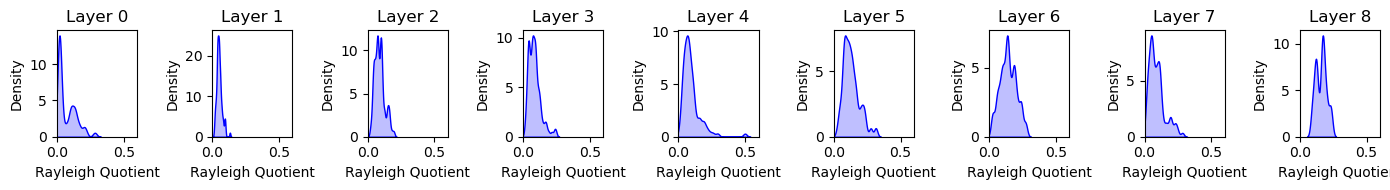

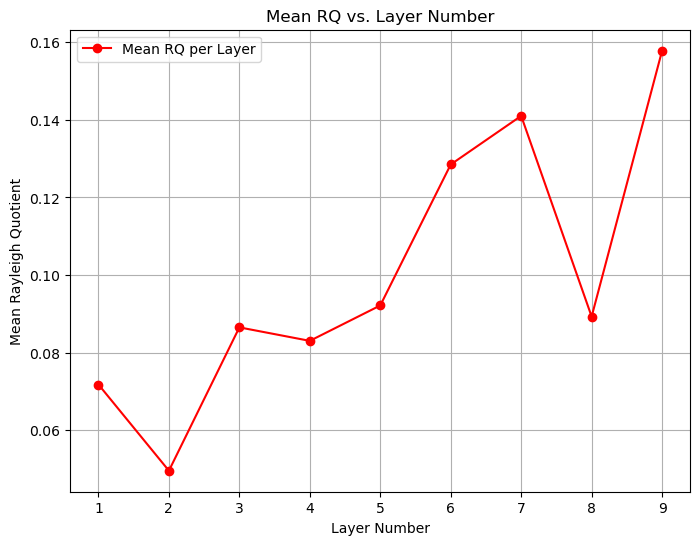

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Number of layers (based on the length of rq_distributions)
num_layers = len(rq_distributions)
print(num_layers)
# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=num_layers, figsize=(14, 2))
mean_rq_per_layer = []

# Loop over each layer and plot the smoothed KDE
for i in range(num_layers):
    #sns.kdeplot(rq_distributions[i], color='b', fill=True, clip=(0, None), bw_adjust=0.5, ax=axes[i])
    sns.kdeplot(rq_distributions[i], color='b', fill=True,  bw_adjust=0.5, ax=axes[i])
    axes[i].set_title(f'Layer {i}')
    axes[i].set_xlabel('Rayleigh Quotient')
    if i==0:
        axes[i].set_ylabel('Density')
    axes[i].set_xlim([0, 0.6])
    mean_rq = np.mean(rq_distributions[i])
    mean_rq_per_layer.append(mean_rq)
    
plt.tight_layout()
plt.show()

# Now plot the mean RQ vs. layer number
plt.figure(figsize=(8, 6))
layer_numbers = np.arange(1, num_layers + 1)
plt.plot(layer_numbers, mean_rq_per_layer, marker='o', linestyle='-', color='r', label='Mean RQ per Layer')
plt.xlabel('Layer Number')
plt.ylabel('Mean Rayleigh Quotient')
plt.title('Mean RQ vs. Layer Number')
plt.grid(True)
plt.legend()
plt.show()

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import copy

def ablation_analysis(net, dataloader, criterion, rq_distributions):
    """
    Perform ablation analysis by removing nodes in the network
    and comparing the loss before and after the ablation.
    """
    layer_importances = []

    # Compute the original loss before ablation
    original_loss = compute_network_loss(net, dataloader, criterion)

    # Loop over each layer
    for layer_idx, layer in enumerate(net.layers):
        layer_importance = []

        # Loop over each node in the layer
        for node_idx in range(layer.out_features):  # Assuming Linear layer
            print(layer_idx, node_idx)
            # Clone the original network to avoid accumulating changes
            net_copy = copy.deepcopy(net)

            # Get the specific layer to ablate in the cloned network
            layer_copy = net_copy.layers[layer_idx]

            # Zero out the node by setting its weights to 0 in the copied network
            ablated_weights = layer_copy.weight.clone()
            ablated_weights[:, node_idx] = 0  # Ablate the node by setting its weights to 0
            layer_copy.weight = nn.Parameter(ablated_weights.to(layer_copy.weight.device))

            # If the layer has bias, update it similarly (if ablation affects bias)
            if layer_copy.bias is not None:
                ablated_bias = layer_copy.bias.clone()
                layer_copy.bias = nn.Parameter(ablated_bias.to(layer_copy.bias.device))

            # Compute loss after ablation on the cloned network
            ablation_loss = compute_network_loss(net_copy, dataloader, criterion)

            # Compute importance as the difference in loss
            importance = ablation_loss - original_loss
            layer_importance.append(importance)

        layer_importances.append(layer_importance)

    return layer_importances



def compute_network_loss(net, dataloader, criterion):
    net.eval()
    total_loss = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)  # Move data to the same device

            images = images.view(images.size(0), -1)  # Flatten the images

            outputs = net(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
    
    return total_loss / total_samples


def plot_rq_vs_importance(rq_distributions, layer_importances):
    """ Plot RQ vs Importance for each layer """
    num_layers = len(rq_distributions)
    
    for layer_idx in range(num_layers):
        plt.figure(figsize=(8, 6))
        plt.scatter(rq_distributions[layer_idx], layer_importances[layer_idx], c='b', alpha=0.6)
        plt.xlabel('Rayleigh Quotient (RQ)')
        plt.ylabel('Importance (Loss Change)')
        plt.title(f'Layer {layer_idx+1}: RQ vs Importance')
        plt.grid(True)
        plt.show()

# Example Usage:
# Assuming you have a fully trained network `net`, a validation dataloader `val_loader`,
# and precomputed `rq_distributions` for each layer.

criterion = torch.nn.CrossEntropyLoss()  # Define your loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Ensure device is set
    
original_loss = compute_network_loss(net, test_loader, criterion)
print(original_loss)

# Perform ablation analysis
layer_importances = ablation_analysis(net, test_loader, criterion, rq_distributions)

# Plot RQ vs Importance for each layer
plot_rq_vs_importance(rq_distributions, layer_importances)

0.5525679546833039


KeyboardInterrupt: 

In [ ]:
# Get the first batch from train_loader
batch = next(iter(train_loader))

# Check if batch contains two elements (images and labels)
print(f"Batch contains: {len(batch)} elements")

# Assuming the batch has images and labels
images, labels = batch

# Check the shapes
print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")

# Example of plotting the first image in the batch
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.show()

In [ ]:
# Extract one batch of data
data_iter = iter(train_loader)
images, labels = data_iter.next()

# Reshape images to 2D (flatten) and compute covariance matrix
images_flat = images.view(images.size(0), -1).numpy()  # Flatten images
cov_matrix = np.cov(images_flat, rowvar=False)  # Compute covariance matrix

# Plot covariance matrix
plt.figure(figsize=(8, 6))
plt.imshow(cov_matrix, cmap='viridis')
plt.title("Covariance Matrix of Normalized Data")
plt.colorbar()
plt.show()

In [ ]:
# Restructure rq_distributions if needed
# Example: Group RQ values by layer
# Parameters of the network
input_size = 28 * 28  # Input layer (e.g., for images)
hidden_sizes = [128, 64]  # Hidden layers
num_classes = 10  # Output layer

# Define number of nodes per layer
num_nodes_per_layer = [input_size] + hidden_sizes + [num_classes]

# Example printout of the number of nodes per layer
print("Number of nodes per layer:", num_nodes_per_layer)

#num_nodes_per_layer = [128, 64, 32]  # Example sizes of each layer
rq_distributions_by_layer = []
start_idx = 0

for num_nodes in num_nodes_per_layer:
    rq_distributions_by_layer.append(rq_distributions[start_idx:start_idx + num_nodes])
    start_idx += num_nodes


# for i, layer_rq in enumerate(rq_distributions):
#     print(f"Layer {i} has {len(layer_rq)} RQ values.")

In [ ]:
# import numpy as np
# import torch

# # Compute Rayleigh Quotient
# def compute_rq(weights, X):
#     """
#     Computes Rayleigh Quotient for given weights and inputs X.
    
#     Parameters:
#     - weights: The weights of the layer (e.g., shape [output_size, input_size]).
#     - X: Input data to the layer (batch_size, input_size).
    
#     Returns:
#     - RQ: The Rayleigh Quotient for the given weights and inputs.
#     """
#     C = X.T @ X  # Covariance matrix
#     numerator = np.dot(weights.T, np.dot(C, weights))
#     denominator = np.dot(weights.T, weights)
#     return numerator / denominator
# # Analyze RQ distributions for different batch sizes
# def analyze_rq_batch_size(net, train_loader, batch_sizes):
#     rq_distributions = []
#     for batch_size in batch_sizes:
#         rqs = []
#         for images, _ in train_loader:
#             images = images.view(images.size(0), -1)  # Flatten the images (batch_size, 28*28)
#             if images.size(0) > batch_size:
#                 images = images[:batch_size]  # Ensure we're only using the current batch size

#             # Forward pass through the network to get activations
#             with torch.no_grad():
#                 output = net(images)

#             # Get weights of the first layer
#             weights = list(net.parameters())[0].detach().numpy()  # (hidden_size, input_size)
            
#             # Compute RQ for the first layer weights and inputs
#             rqs.append(compute_rq(weights, images.numpy()))  
        
#         rq_distributions.append(np.array(rqs).flatten())  # Store RQ distribution for this batch size
    
#     return rq_distributions

# # Example usage:
# batch_sizes = [16, 32, 64, 128]  # Test different batch sizes
# train_loader, _ = load_datasets(batch_size=batch_sizes[0])  # Assuming you have a function for loading datasets
# net = MultilayerNet(input_size=28*28, hidden_sizes=[128, 64], num_classes=10)  # Define network

# # Analyze the RQ distribution for different batch sizes
# rq_distributions = analyze_rq_batch_size(net, train_loader, batch_sizes)

# # Now plot or further analyze the rq_distributions for each batch size

In [ ]:
import numpy as np
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt



# Compute Mutual Information (MI) between input and predicted labels
def compute_mutual_information(X, Y, n_bins=10):
    X_flat = X.reshape(X.shape[0], -1)

    # Binning using KBinsDiscretizer
    discretizer_X = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
    X_binned = discretizer_X.fit_transform(X_flat)

    # Compute MI for each sample in the batch
    mi_values = []
    for i in range(X_binned.shape[0]):
        mi_values.append(mutual_info_score(X_binned[i], Y))  # Compare binned input with predicted labels
    
    return np.mean(mi_values)

# Analyze MI vs RQ values for the trained network
def analyze_mi_vs_rq(net, dataset, device, n_bins=10):
    rq_values = []
    mi_values = []
    
    for images, _ in dataset:
        images = images.to(device).view(images.size(0), -1)  # Flatten images
        with torch.no_grad():
            output = net(images)
            predicted_labels = torch.argmax(output, dim=1).cpu().numpy()  # Get predicted class labels
        
        # Get weights of the first layer (for example)
        weights = list(net.parameters())[0].detach().cpu().numpy()
        
        # Compute RQ for the first layer weights and inputs
        rq_values.append(compute_rq(weights, images.cpu().numpy()))
        
        # Compute MI between inputs and predicted labels
        mi = compute_mutual_information(images.cpu().numpy(), predicted_labels, n_bins=n_bins)
        mi_values.append(mi)
    
    # Flatten and align lengths of RQ and MI values
    rq_values = np.concatenate(rq_values, axis=0)
    mi_values = np.array(mi_values)

    min_length = min(len(rq_values), len(mi_values))
    return rq_values[:min_length], mi_values[:min_length]

# Plot RQ vs MI
def plot_mi_vs_rq(rq_values, mi_values):
    """Plot MI vs RQ"""
    plt.figure(figsize=(8, 6))
    plt.scatter(rq_values, mi_values, c='blue', alpha=0.5)
    plt.xlabel('RQ Score')
    plt.ylabel('Mutual Information')
    plt.title('Mutual Information vs RQ Score')
    plt.grid(True)
    plt.show()

# Perform MI vs RQ analysis on the trained network
device = 'cpu'
rq_values, mi_values = analyze_mi_vs_rq(trained_net, train_loader, device, n_bins=10)
plot_mi_vs_rq(rq_values, mi_values)

In [ ]:
# Loading a different dataset
def load_cifar10(batch_size):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
    
    train_loader = DataLoader.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# Training with different cost functions
def train_with_cost_function(net, train_loader, cost_function):
    optimizer = optim.Adam(net.parameters(), lr=0.001)
    
    for epoch in range(5):  # Limited epochs for experimentation
        for images, labels in train_loader:
            images = images.view(images.size(0), -1)  # Flatten input
            optimizer.zero_grad()
            outputs = net(images)
            
            # Compute loss based on the provided cost function
            if cost_function == 'cross_entropy':
                loss = nn.CrossEntropyLoss()(outputs, labels)
            elif cost_function == 'mse':
                labels_one_hot = nn.functional.one_hot(labels, num_classes=10).float()
                loss = nn.MSELoss()(outputs, labels_one_hot)
            
            loss.backward()
            optimizer.step()

# Example usage
train_loader, test_loader = load_cifar10(batch_size=64)
net = MultilayerNet(input_size=32*32*3, hidden_sizes=[256, 128], num_classes=10)
train_with_cost_function(net, train_loader, cost_function='cross_entropy')

In [ ]:
# Loading a different dataset
def load_cifar10(batch_size):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
    
    train_loader = DataLoader.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# Training with different cost functions
def train_with_cost_function(net, train_loader, cost_function):
    optimizer = optim.Adam(net.parameters(), lr=0.001)
    
    for epoch in range(5):  # Limited epochs for experimentation
        for images, labels in train_loader:
            images = images.view(images.size(0), -1)  # Flatten input
            optimizer.zero_grad()
            outputs = net(images)
            
            # Compute loss based on the provided cost function
            if cost_function == 'cross_entropy':
                loss = nn.CrossEntropyLoss()(outputs, labels)
            elif cost_function == 'mse':
                labels_one_hot = nn.functional.one_hot(labels, num_classes=10).float()
                loss = nn.MSELoss()(outputs, labels_one_hot)
            
            loss.backward()
            optimizer.step()

# Example usage
train_loader, test_loader = load_cifar10(batch_size=64)
net = MultilayerNet(input_size=32*32*3, hidden_sizes=[256, 128], num_classes=10)
train_with_cost_function(net, train_loader, cost_function='cross_entropy')